<a href="https://colab.research.google.com/github/jesusthayna60-gif/custos_de_producao/blob/main/Projeto_Final_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('y1AQEIpMTR2j7xgr9MH0_Manufacturing Dataset.csv')

In [ ]:
df

,Production ID,Date,Product Type,Machine ID,Shift,Units Produced,Defects,Production Time Hours,Material Cost Per Unit,Labour Cost Per Hour,Energy Consumption kWh,Operator Count,Maintenance Hours,Down time Hours,Production Volume Cubic Meters,Scrap Rate,Rework Hours,Quality Checks Failed,Average Temperature C,Average Humidity Percent
0,1899-12-31,2020-01-01,Automotive,3,Swing,142,3.0,23.42,38.68,15.38,413.97,1,4.86,1.57,2.34,0.048,1.65,1,22.8,47.2
1,1900-01-01,2020-01-02,Textiles,8,Night,170,4.0,7.51,21.35,25.36,181.16,2,2.51,0.18,1.52,0.030,NaN,1,23.8,37.9
2,1900-01-02,2020-01-03,Appliances,11,Swing,182,4.0,20.58,47.54,16.46,452.15,2,0.34,2.88,0.57,0.026,0.26,0,24.5,56.1
3,1900-01-03,2020-01-04,Appliances,11,Day,133,NaN,21.68,40.21,28.70,485.78,3,4.64,2.23,1.90,0.036,NaN,2,22.3,50.8
4,1900-01-04,2020-01-05,Electronics,14,Night,82,NaN,16.68,38.02,17.20,315.58,1,2.29,0.02,2.25,0.020,0.67,0,23.4,53.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,1908-03-14,2028-03-14,Automotive,3,Swing,194,7.0,20.74,16.91,15.94,215.04,4,3.06,2.28,1.03,0.021,0.51,1,21.6,53.6
2996,1908-03-15,2028-03-15,Electronics,13,Swing,119,4.0,14.77,34.50,25.95,291.65,2,2.27,0.80,2.09,0.016,1.22,2,24.2,50.9
2997,2998,2028-03-16,Appliances,9,Day,170,2.0,20.38,33.02,18.61,313.24,1,4.66,1.86,1.41,0.047,0.19,0,24.2,51.4
2998,2999,2028-03-17,Furniture,20,Swing,199,3.0,1.01,24.35,29.73,245.47,3,2.73,0.26,0.93,0.029,1.26,1,24.9,56.3


In [ ]:
df.head()

,Production ID,Date,Product Type,Machine ID,Shift,Units Produced,Defects,Production Time Hours,Material Cost Per Unit,Labour Cost Per Hour,Energy Consumption kWh,Operator Count,Maintenance Hours,Down time Hours,Production Volume Cubic Meters,Scrap Rate,Rework Hours,Quality Checks Failed,Average Temperature C,Average Humidity Percent
0,1899-12-31,2020-01-01,Automotive,3,Swing,142,3.0,23.42,38.68,15.38,413.97,1,4.86,1.57,2.34,0.048,1.65,1,22.8,47.2
1,1900-01-01,2020-01-02,Textiles,8,Night,170,4.0,7.51,21.35,25.36,181.16,2,2.51,0.18,1.52,0.030,NaN,1,23.8,37.9
2,1900-01-02,2020-01-03,Appliances,11,Swing,182,4.0,20.58,47.54,16.46,452.15,2,0.34,2.88,0.57,0.026,0.26,0,24.5,56.1
3,1900-01-03,2020-01-04,Appliances,11,Day,133,NaN,21.68,40.21,28.70,485.78,3,4.64,2.23,1.90,0.036,NaN,2,22.3,50.8
4,1900-01-04,2020-01-05,Electronics,14,Night,82,NaN,16.68,38.02,17.20,315.58,1,2.29,0.02,2.25,0.020,0.67,0,23.4,53.9


In [ ]:
'''Cada linha do arquivo CSV representa um único registro de produção, um ciclo de produção descrito pelos dados: ID da Produção, Data, Tipo do Produto, ID da Máquina, Turno'''

'Cada linha do arquivo CSV representa um único registro de produção, um ciclo de produção descrito pelos dados: ID da Produção, Data, Tipo do Produto, ID da Máquina, Turno'

In [ ]:
df.columns

Index(['Production ID', 'Date', 'Product Type', 'Machine ID', 'Shift',
       'Units Produced', 'Defects', 'Production Time Hours',
       'Material Cost Per Unit', 'Labour Cost Per Hour',
       'Energy Consumption kWh', 'Operator Count', 'Maintenance Hours',
       'Down time Hours', 'Production Volume Cubic Meters', 'Scrap Rate',
       'Rework Hours', 'Quality Checks Failed', 'Average Temperature C',
       'Average Humidity Percent'],
      dtype='object')

In [35]:
#Calculo de Custos totais de acordo com os dados de produção.
df['Custo Material'] = df['Material Cost Per Unit'] * df['Units Produced']
df['Custo de Mão de Obra'] = df['Labour Cost Per Hour'] * df['Production Time Hours']

#Para calcular o valor da Energia tivemos que adotar um valor para o kWh. Disponível no site: https://clarke.com.br/mapa-de-tarifas-de-energia-no-brasil/#principal
valor_por_kWh = 0.82
df['Custo de Energia'] = df['Energy Consumption kWh'] * valor_por_kWh

df['Custo Total'] = df['Custo Material'] + df['Custo de Mão de Obra'] + df['Custo de Energia']
df['Custo Total']

# O próximo passo é calcular o preço/unidade, para termos um parâmetro padronizado para compações e posteriormente relacionar com outros dados.

df['Custo por Unidade'] = df['Custo Total'] / df['Units Produced']

colunas_custo = ['Date','Custo Material',
                 'Custo de Mão de Obra',
                 'Custo de Energia',
                 'Custo Total',
                 'Custo por Unidade']
df[colunas_custo].head()

,Date,Custo Material,Custo de Mão de Obra,Custo de Energia,Custo Total,Custo por Unidade
0,2020-01-01,5492.56,360.1996,339.4554,6192.2150,43.607148
1,2020-01-02,3629.50,190.4536,148.5512,3968.5048,23.344146
2,2020-01-03,8652.28,338.7468,370.7630,9361.7898,51.438405
3,2020-01-04,5347.93,622.2160,398.3396,6368.4856,47.883350
4,2020-01-05,3117.64,286.8960,258.7756,3663.3116,44.674532


In [ ]:
# Cálculo do custo médio por unidade de cada tipo de produto
custo_medio_por_unidade_produto = df.groupby('Product Type')['Custo por Unidade'].mean()
print("Custo Médio por Unidade (R$/Unidade) por Tipo de Produto")
print(round(custo_medio_por_unidade_produto,3))

Custo Médio por Unidade (R$/Unidade) por Tipo de Produto
Product Type
Appliances     34.597
Automotive     34.839
Electronics    35.982
Furniture      36.275
Textiles       34.020
Name: Custo por Unidade, dtype: float64


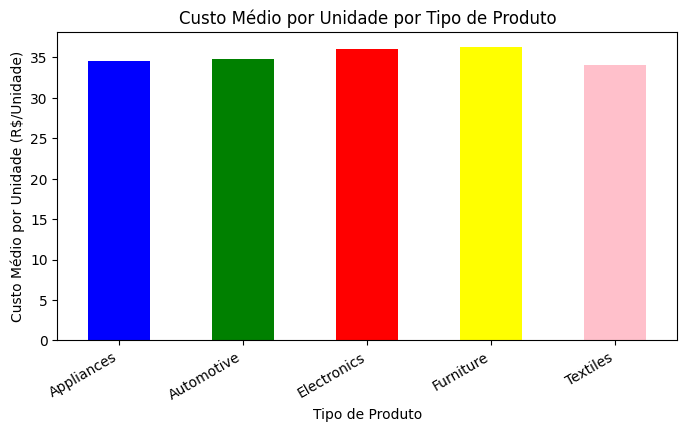

In [ ]:
# Gráfico do Custo médio por unidade versus o tipo de produto
plt.figure(figsize=(8, 4))
colors = ['blue', 'green', 'red', 'yellow', 'pink']
custo_medio_por_unidade_produto.plot(kind='bar', color=colors)
plt.title('Custo Médio por Unidade por Tipo de Produto')
plt.xlabel('Tipo de Produto')
plt.ylabel('Custo Médio por Unidade (R$/Unidade)')
plt.xticks(rotation=30, ha='right')
plt.show()

In [ ]:
# Observamos que os valores médios de produção de cada tipo de produto são proximos.
# Não parece tão relevante uma comparação entre eles.
# Vamos analizar a influência de cada custo.

custo_total_material = df['Custo Material'].sum()
custo_total_labour = df['Custo de Mão de Obra'].sum()
custo_total_energy = df['Custo de Energia'].sum()

custo_total_absoluto = df['Custo Total'].sum()
print('O custo total da indústria é R$', round(custo_total_absoluto,2))

# Calculo de porcentagens:
custo_total_material_percent = (custo_total_material / custo_total_absoluto) * 100
custo_total_labour_percent = (custo_total_labour / custo_total_absoluto) * 100
custo_total_energy_percent = (custo_total_energy / custo_total_absoluto) * 100

#Exibição dos resultados
print('A porcentagem do custo de material é de: ', round(custo_total_material_percent, 2), '%')
print('A porcentagem do custo de mão de obra é de: ', round(custo_total_labour_percent,2), '%')
print('A porcentagem do custo de energia é de: ', round(custo_total_energy_percent,2), '%')

O custo total da indústria é R$ 12924988.11
A porcentagem do custo de material é de:  87.68 %
A porcentagem do custo de mão de obra é de:  6.61 %
A porcentagem do custo de energia é de:  5.71 %


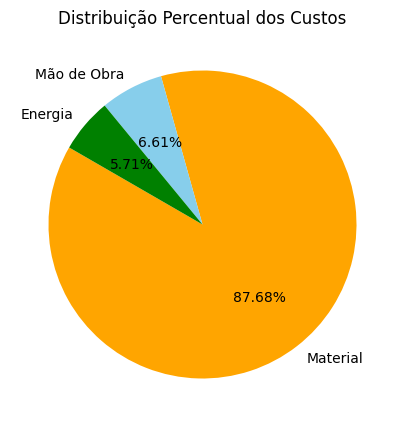

In [ ]:
# Dados para o gráfico de pizza relacionando os tipos de custos da indústria
labels = ['Material', 'Mão de Obra', 'Energia']
custos_porcentagens = [custo_total_material_percent,
         custo_total_labour_percent,
         custo_total_energy_percent]
colors = ['orange', 'skyblue', 'green']

plt.figure(figsize=(10, 5))
plt.pie(custos_porcentagens, labels=labels, colors=colors, autopct='%1.2f%%', startangle=150)
plt.title('Distribuição Percentual dos Custos')
plt.show()